# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
csv_path = "../data/regression.csv"
df = pd.read_csv(csv_path)

In [3]:
df = df.drop(columns=['pageviews'])
X = df[['num_commits', 'AVG(diff)']]

## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [4]:
kmeans = KMeans(random_state=21, n_clusters=3)
labels = kmeans.fit_predict(X)

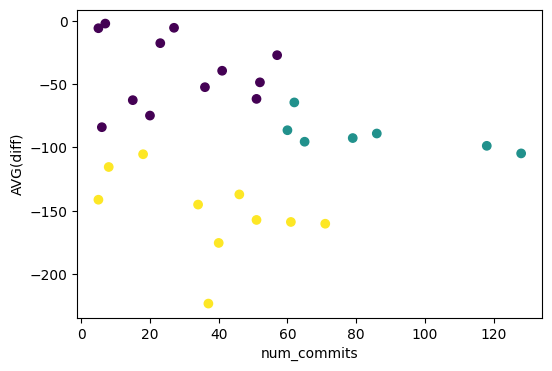

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

In [6]:
for n in range(2, 11):
    kmeans = KMeans(random_state=21, n_clusters=n)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'n_clusters={n}, silhouette_score={score:.4f}')

n_clusters=2, silhouette_score=0.4179
n_clusters=3, silhouette_score=0.4390
n_clusters=4, silhouette_score=0.4397
n_clusters=5, silhouette_score=0.4464
n_clusters=6, silhouette_score=0.4457
n_clusters=7, silhouette_score=0.4964
n_clusters=8, silhouette_score=0.5078
n_clusters=9, silhouette_score=0.4561
n_clusters=10, silhouette_score=0.4254


In [7]:
best_kmeans = KMeans(random_state=21, n_clusters=8)
labels = best_kmeans.fit_predict(X)

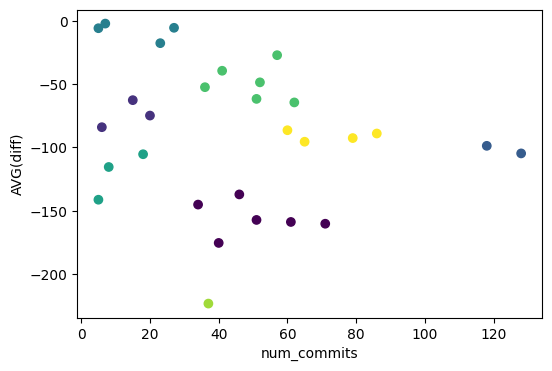

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [9]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels = dbscan.fit_predict(X)

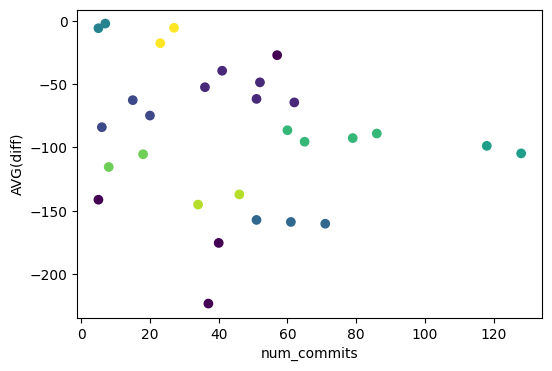

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

In [11]:
for eps in np.arange(10, 30, 2):
    for ms in [1, 2, 3]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
            print(f'eps={eps}, min_samples={ms}, silhouette={score:.4f}')

eps=10, min_samples=1, silhouette=0.0928
eps=10, min_samples=2, silhouette=-0.0792
eps=12, min_samples=1, silhouette=0.2484
eps=12, min_samples=2, silhouette=0.0459
eps=12, min_samples=3, silhouette=0.1716
eps=14, min_samples=1, silhouette=0.3310
eps=14, min_samples=2, silhouette=0.2520
eps=14, min_samples=3, silhouette=-0.1555
eps=16, min_samples=1, silhouette=0.3970
eps=16, min_samples=2, silhouette=0.3470
eps=16, min_samples=3, silhouette=-0.0060
eps=18, min_samples=1, silhouette=0.4322
eps=18, min_samples=2, silhouette=0.3834
eps=18, min_samples=3, silhouette=0.0467
eps=20, min_samples=1, silhouette=0.4322
eps=20, min_samples=2, silhouette=0.3834
eps=20, min_samples=3, silhouette=0.0467
eps=22, min_samples=1, silhouette=0.4871
eps=22, min_samples=2, silhouette=0.4794
eps=22, min_samples=3, silhouette=0.3596
eps=24, min_samples=1, silhouette=0.3378
eps=24, min_samples=2, silhouette=0.3373
eps=24, min_samples=3, silhouette=0.3192
eps=26, min_samples=1, silhouette=0.2997
eps=26, min_s

In [12]:
best_dbscan = DBSCAN(eps=22, min_samples=1)
labels = best_dbscan.fit_predict(X)

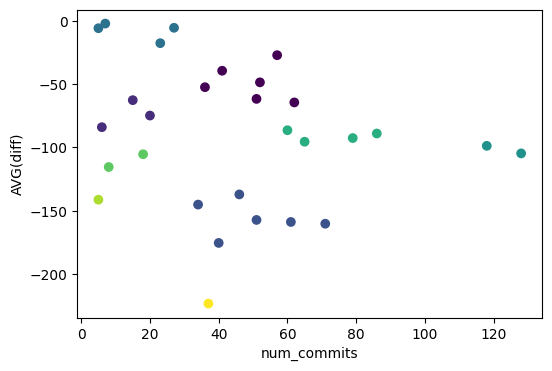

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [14]:
agg = AgglomerativeClustering(n_clusters=5)
labels = agg.fit_predict(X)

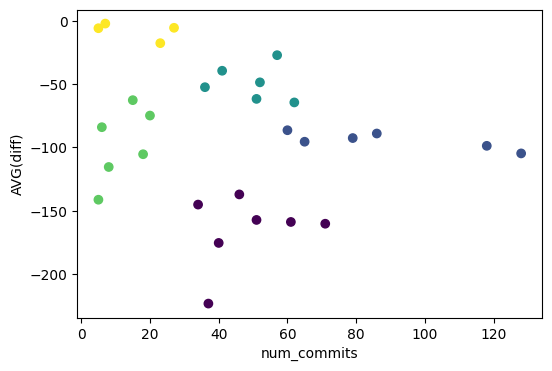

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

In [16]:
for n in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=n)
    labels = agg.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'n_clusters={n}, silhouette_score={score:.4f}')

n_clusters=2, silhouette_score=0.3590
n_clusters=3, silhouette_score=0.3390
n_clusters=4, silhouette_score=0.4448
n_clusters=5, silhouette_score=0.4638
n_clusters=6, silhouette_score=0.4527
n_clusters=7, silhouette_score=0.4866
n_clusters=8, silhouette_score=0.5078
n_clusters=9, silhouette_score=0.4758
n_clusters=10, silhouette_score=0.4312


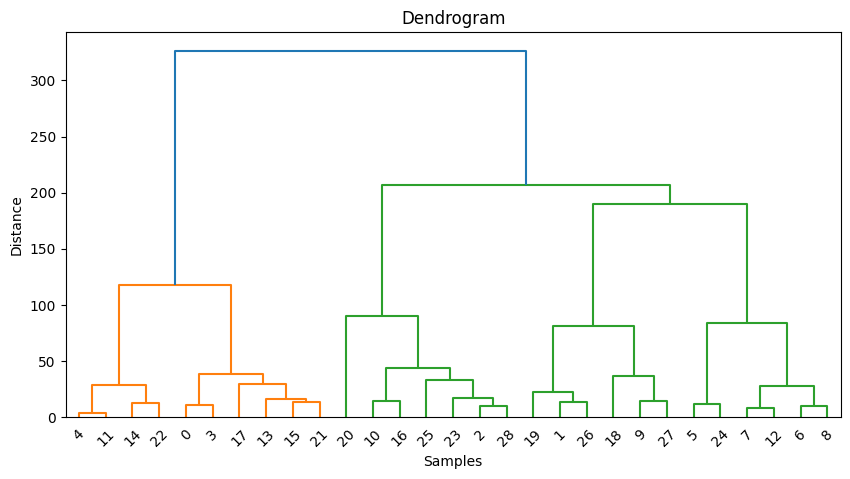

In [17]:
Z = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [18]:
def optimize_clustering(Model, param_name, param_range, X, **fixed_params):
    scores = []
    best_score = -1
    best_model = None
    best_value = None

    for value in param_range:
        params = fixed_params.copy()
        params[param_name] = value
        model = Model(**params)
        labels = model.fit_predict(X)

        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
        else:
            score = -1

        scores.append(score)

        if score > best_score:
            best_score = score
            best_model = model
            best_value = value

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(param_range, scores, marker='o')
    plt.title(f'Silhouette score vs {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('silhouette_score')

    plt.subplot(1, 2, 2)
    labels = best_model.fit_predict(X)
    plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='viridis')
    plt.title(f'Best clustering ({param_name}={best_value})')
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.show()

    return best_model, best_value, best_score

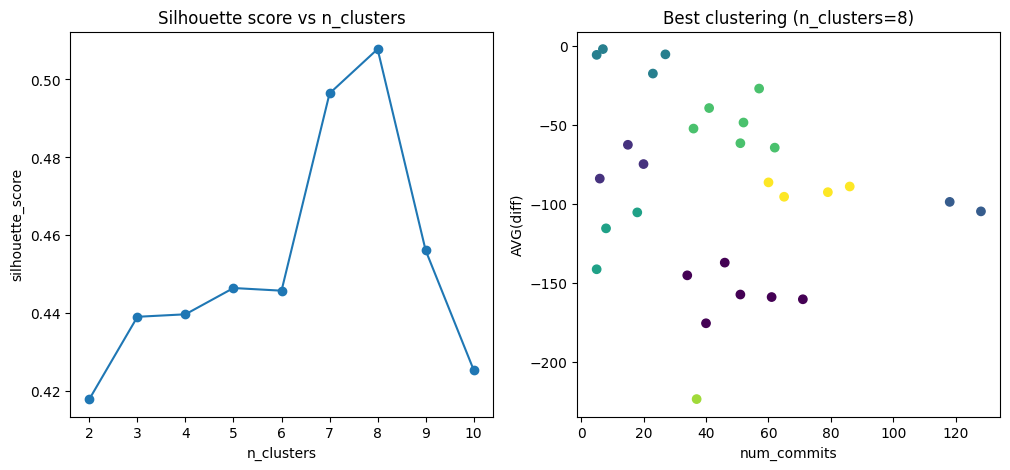

In [19]:
best_kmeans, best_n, score = optimize_clustering(
    KMeans, 'n_clusters', range(2, 11), X, random_state=21
)

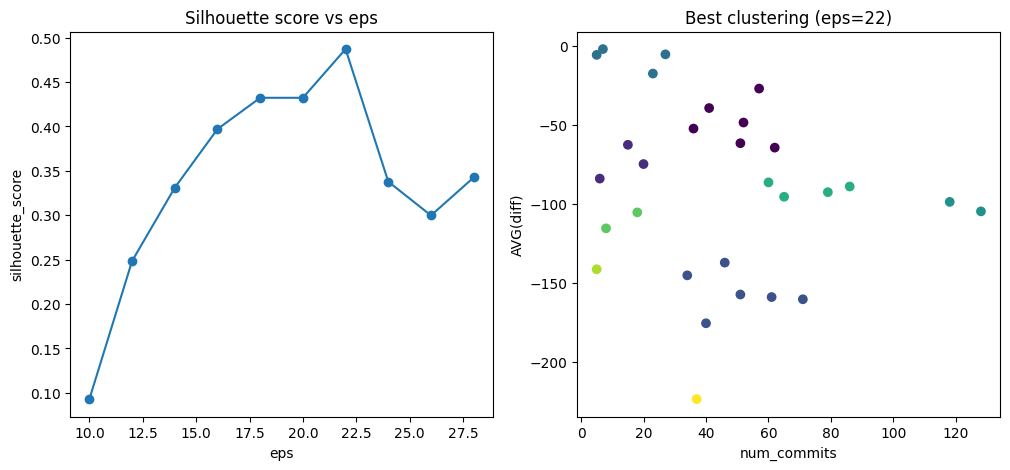

In [20]:
best_dbscan, best_eps, score = optimize_clustering(
    DBSCAN, 'eps', np.arange(10, 30, 2), X, min_samples=1
)

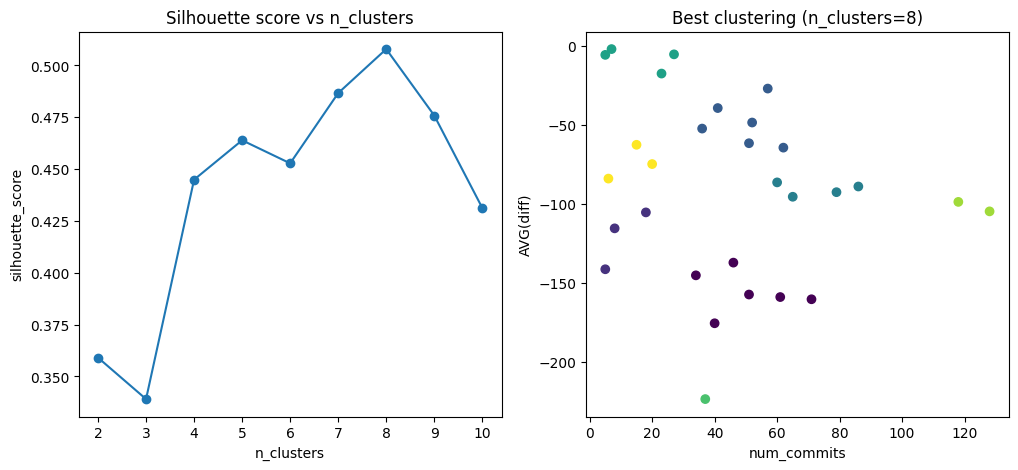

In [21]:
best_agg, best_n, score = optimize_clustering(
    AgglomerativeClustering, 'n_clusters', range(2, 11), X
)